# STUDENT MENTAL HEALTH & BURNOUT ANALYSIS
# Models: Linear Regression, Logistic Regression,
# Random Forest Classifier

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, classification_report,
    confusion_matrix
)

STEP 1 — LOAD DATA

In [22]:
import pandas as pd
df = pd.read_csv("student_mental_health_burnout_1M.csv.xls")
# Use only 100,000 random rows for faster training
df = df.sample(n=100000, random_state=42).reset_index(drop=True)
print("Shape of dataset:", df.shape)   # rows, columns
print()
df.head()

Shape of dataset: (100000, 20)



,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,19,Male,1,3.189878,4.638069,70.502920,3.341312,0.099703,0.719136,5.990969,1.794705,4.999102,5.775392,5.526426,4.104480,6.048954,0.615961,8.417823,Low,0.385568
1,21,Female,1,7.881451,6.760116,73.247098,5.347451,4.418133,0.024451,6.212258,2.170758,8.157403,7.192148,5.988542,1.829564,7.372226,2.618701,6.528244,Low,0.000000
2,17,Female,4,3.236521,5.691440,69.259244,3.566456,2.479518,0.000000,7.101865,0.819740,7.306309,2.513446,3.464870,6.945419,5.545514,0.000000,7.829562,Low,1.649955
3,17,Male,3,5.593783,5.927521,68.375104,5.963178,4.451211,1.168679,3.145930,2.538738,5.394288,3.040054,3.142998,7.278448,2.576577,4.608672,5.928762,Medium,1.442608
4,25,Male,4,2.594312,4.030860,67.057743,3.072377,1.424443,0.549456,6.243598,2.859210,6.272302,7.721106,7.799291,6.473021,4.199195,0.057824,8.178880,Low,0.000000


 STEP 2 — BASIC INFO & MISSING VALUES

In [23]:
print(df.info())
print()
print("Missing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   age                   100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   academic_year         100000 non-null  int64  
 3   study_hours_per_day   100000 non-null  float64
 4   exam_pressure         100000 non-null  float64
 5   academic_performance  100000 non-null  float64
 6   stress_level          100000 non-null  float64
 7   anxiety_score         100000 non-null  float64
 8   depression_score      100000 non-null  float64
 9   sleep_hours           100000 non-null  float64
 10  physical_activity     100000 non-null  float64
 11  social_support        100000 non-null  float64
 12  screen_time           100000 non-null  float64
 13  internet_usage        100000 non-null  float64
 14  financial_stress      100000 non-null  float64
 15  f

STEP 3 — SOME QUICK STATS

In [24]:
print("Average study hours per day :", df['study_hours_per_day'].mean())
print("Average sleep hours         :", df['sleep_hours'].mean())
print("Average burnout score       :", df['burnout_score'].mean())
print()
print("Risk level categories:", df['risk_level'].unique())
print("Gender categories    :", df['gender'].unique())


Average study hours per day : 5.0071128421085485
Average sleep hours         : 6.496032732548605
Average burnout score       : 1.7890238955194826

Risk level categories: ['Low' 'Medium' 'High']
Gender categories    : ['Male' 'Female' 'Other']


STEP 4 — VISUALIZATIONS

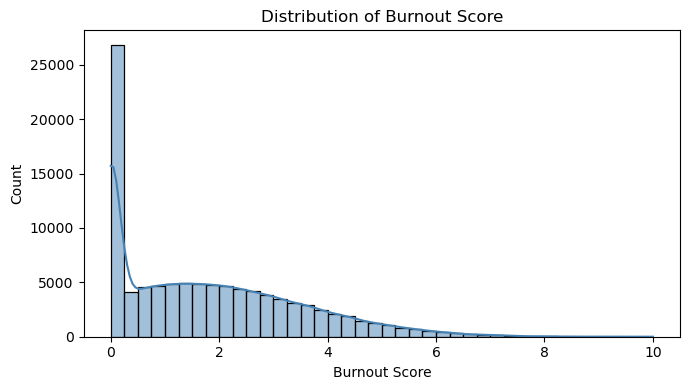

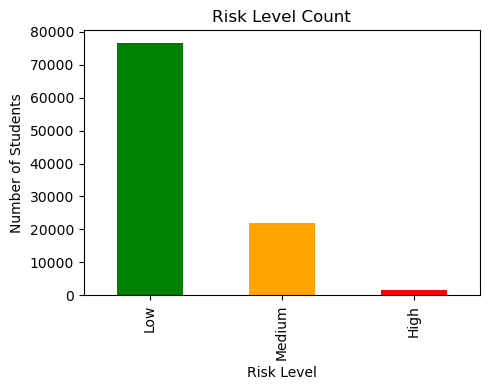

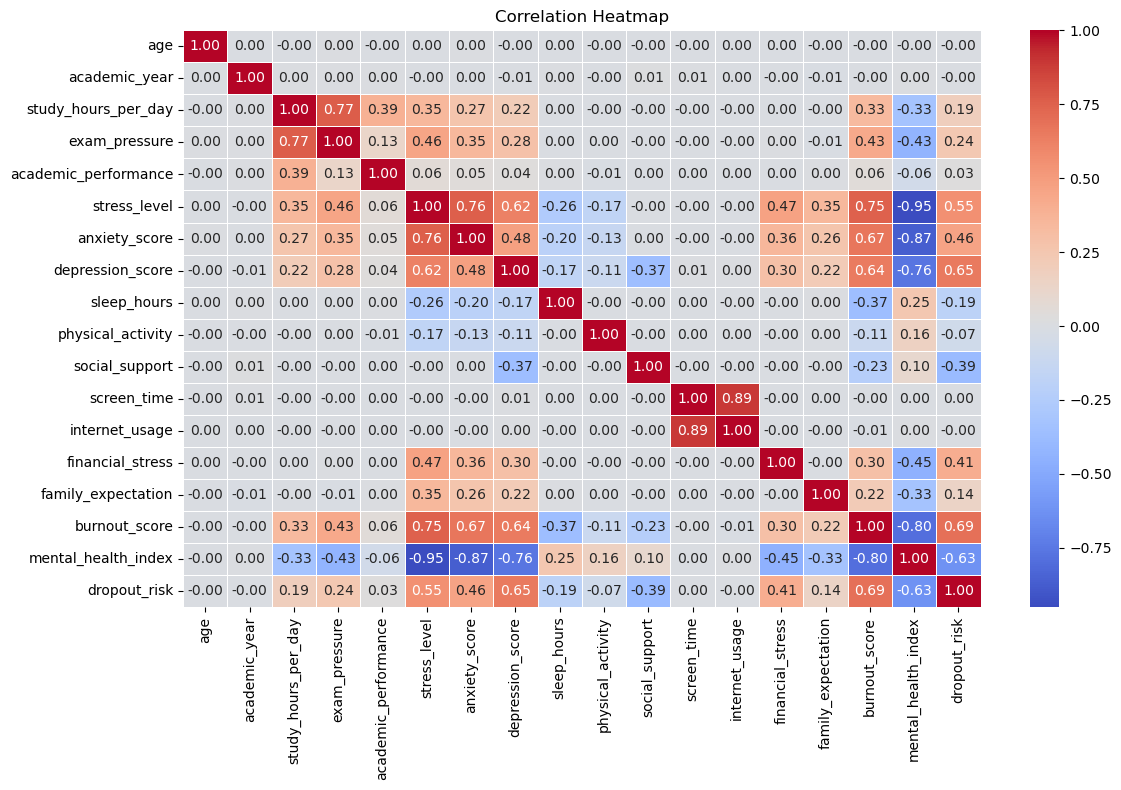

In [25]:
# 4-A: Burnout score distribution
plt.figure(figsize=(7, 4))
sns.histplot(df['burnout_score'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Burnout Score')
plt.xlabel('Burnout Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 4-B: Risk level count
plt.figure(figsize=(5, 4))
df['risk_level'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Risk Level Count')
plt.xlabel('Risk Level')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

# 4-C: Correlation heatmap (numeric columns only)
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

STEP 5 — ENCODE CATEGORICAL COLUMNS
(convert text to numbers so models understand)

In [26]:
# gender: Male → 1, Female → 0
df['gender'] = np.where(df['gender'] == 'Male', 1, 0)

# risk_level: Low → 0, Medium → 1, High → 2
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['risk_level_enc'] = df['risk_level'].map(risk_map)

print(df[['gender', 'risk_level', 'risk_level_enc']].head(5))

   gender risk_level  risk_level_enc
0       1        Low               0
1       0        Low               0
2       0        Low               0
3       1     Medium               1
4       1        Low               0


 STEP 6 — PREPARE FEATURES & TARGETS

We remove columns that are targets or are
derived from other columns (would cause data leakage)

In [27]:
drop_these = ['burnout_score', 'risk_level', 'risk_level_enc',
              'dropout_risk', 'mental_health_index']

# --- REGRESSION target: burnout_score (continuous number) ---
y_reg = df['burnout_score']
X     = df.drop(columns=drop_these)   # features (same for all models)

# --- CLASSIFICATION target: risk_level (Low/Medium/High) ---
y_clf = df['risk_level_enc']

print("Features used:", X.columns.tolist())
print("Feature shape:", X.shape)


Features used: ['age', 'gender', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation']
Feature shape: (100000, 16)


 STEP 7 — TRAIN / TEST SPLIT
 
75% training data, 25% testing data

In [28]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.25, random_state=42
)

# same split for classification
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 75000
Testing  samples : 25000


 # MODEL 1 — LINEAR REGRESSION
  Goal: predict the exact burnout_score


  MODEL 1: LINEAR REGRESSION — predict burnout_score
R² Score : 0.7078
RMSE     : 0.9033


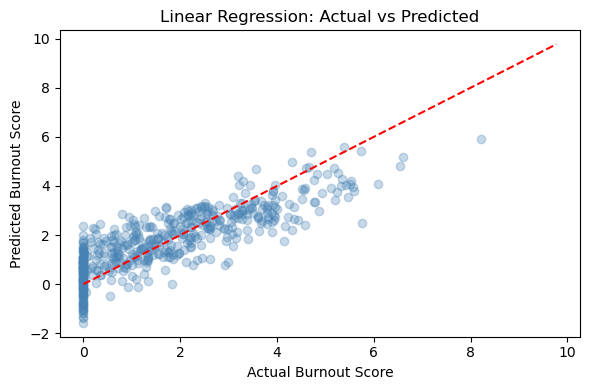


Sample predicted burnout score: 5.21


In [29]:
print("\n" + "="*50)
print("  MODEL 1: LINEAR REGRESSION — predict burnout_score")
print("="*50)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train_reg)

y_pred_lr = lr_model.predict(X_test)

print(f"R² Score : {r2_score(y_test_reg, y_pred_lr):.4f}")
# R² close to 1 = model explains the data well
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)):.4f}")
# RMSE = average error in the same unit as burnout_score

# Visualize actual vs predicted
plt.figure(figsize=(6, 4))
plt.scatter(y_test_reg[:500], y_pred_lr[:500], alpha=0.3, color='steelblue')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Actual Burnout Score')
plt.ylabel('Predicted Burnout Score')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

# Sample prediction
# [age, gender(1=M/0=F), academic_year, study_h, exam_pressure,
#  acad_perf, stress, anxiety, depression, sleep_h, physical_activity,
#  social_support, screen_time, internet_usage, financial_stress, family_expectation]
sample = pd.DataFrame([[22, 1, 3, 6, 8, 65, 7, 6, 5, 5, 3, 4, 5, 4, 6, 7]],
                       columns=X.columns)
print(f"\nSample predicted burnout score: {lr_model.predict(sample)[0]:.2f}")



# MODEL 2 — LOGISTIC REGRESSION
  
 Goal: classify risk_level (Low / Medium / High)

 


  MODEL 2: LOGISTIC REGRESSION — predict risk_level
Accuracy: 0.2985

Classification Report:
              precision    recall  f1-score   support

         Low       0.77      0.32      0.45     19163
      Medium       0.22      0.23      0.22      5463
        High       0.02      0.46      0.03       374

    accuracy                           0.30     25000
   macro avg       0.33      0.34      0.23     25000
weighted avg       0.64      0.30      0.39     25000



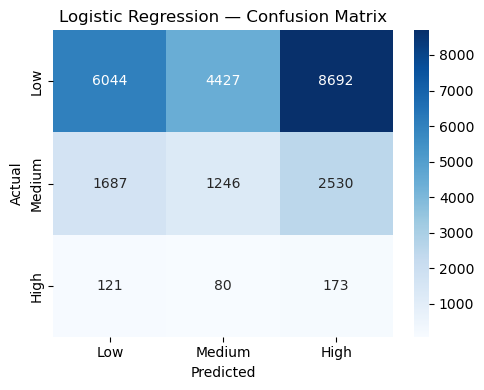

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n" + "="*50)
print("  MODEL 2: LOGISTIC REGRESSION — predict risk_level")
print("="*50)

# -----------------------------
# Scale the features
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Logistic Regression Model
# -----------------------------
log_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

# Train the model
log_model.fit(X_train_scaled, y_train_clf)

# Make predictions
y_pred_log = log_model.predict(X_test_scaled)

# -----------------------------
# Model Evaluation
# -----------------------------
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_log):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_clf,
    y_pred_log,
    target_names=['Low', 'Medium', 'High'],
    zero_division=0
))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test_clf, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()


 # MODEL 3 — RANDOM FOREST CLASSIFIER
 
  Goal: classify risk_level (Low / Medium / High)
  (usually more accurate than logistic regression)



      MODEL 3: IMPROVED RANDOM FOREST CLASSIFIER
Original Training Shape : (75000, 16)
Balanced Training Shape : (172473, 16)

Accuracy : 0.6154

Classification Report:

              precision    recall  f1-score   support

         Low       0.77      0.74      0.75     19163
      Medium       0.22      0.23      0.22      5463
        High       0.01      0.02      0.02       374

    accuracy                           0.62     25000
   macro avg       0.33      0.33      0.33     25000
weighted avg       0.63      0.62      0.62     25000



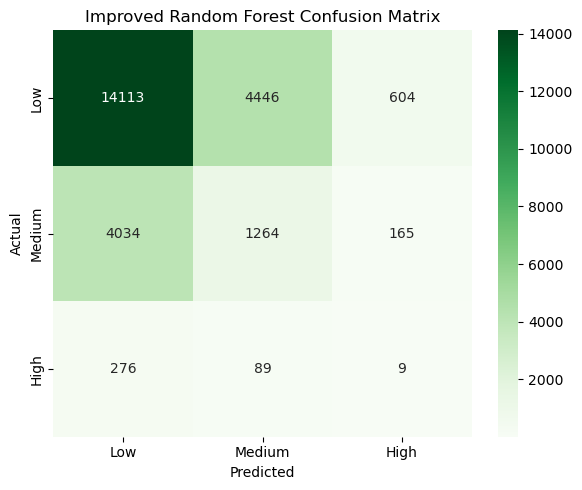


Top 10 Important Features:

academic_performance    0.087511
family_expectation      0.072581
physical_activity       0.069725
social_support          0.069038
sleep_hours             0.067754
financial_stress        0.067750
screen_time             0.066924
internet_usage          0.066814
study_hours_per_day     0.066648
exam_pressure           0.065236
dtype: float64


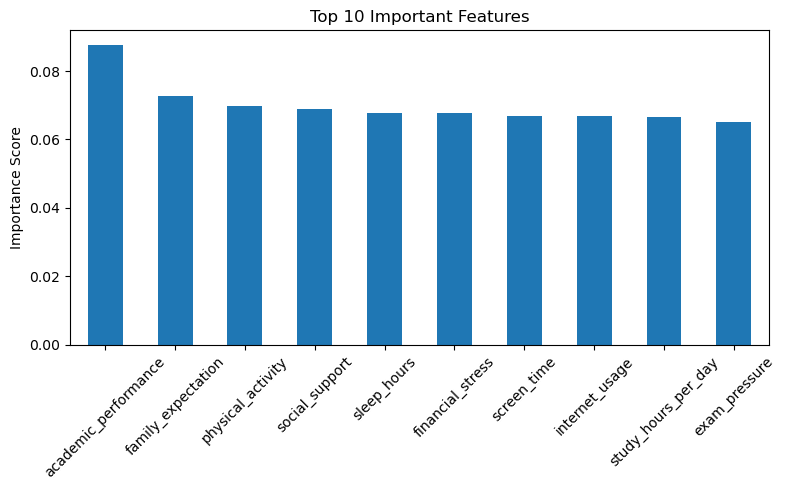


Top 8 Important Features:

academic_performance    0.087511
family_expectation      0.072581
physical_activity       0.069725
social_support          0.069038
sleep_hours             0.067754
financial_stress        0.067750
screen_time             0.066924
internet_usage          0.066814
dtype: float64


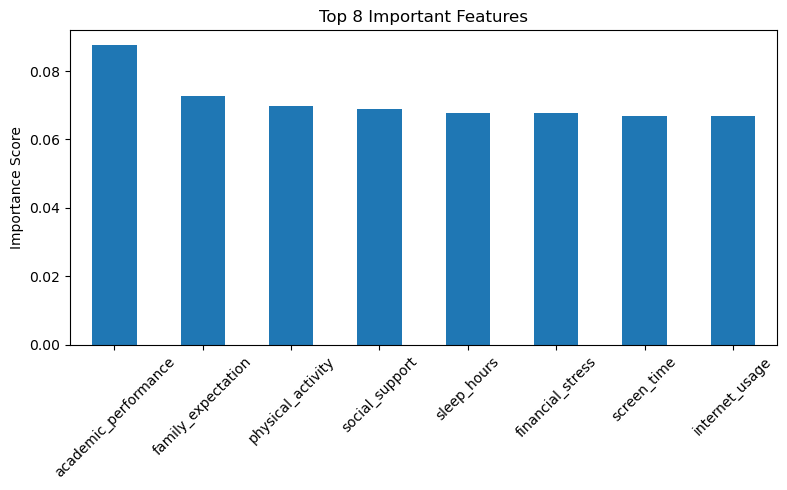

In [34]:
# ════════════════════════════════════════════════════════════════
# MODEL 3 — IMPROVED RANDOM FOREST CLASSIFIER
# Goal: Predict Risk Level (Low / Medium / High)
# ════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("      MODEL 3: IMPROVED RANDOM FOREST CLASSIFIER")
print("="*60)

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -------------------------------------------------------
# Balance the training data using SMOTE
# -------------------------------------------------------

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train_clf
)

print("Original Training Shape :", X_train.shape)
print("Balanced Training Shape :", X_train_smote.shape)

# -------------------------------------------------------
# Improved Random Forest
# -------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred_rf = rf_model.predict(X_test)

# -------------------------------------------------------
# Evaluation
# -------------------------------------------------------

accuracy = accuracy_score(y_test_clf, y_pred_rf)

print(f"\nAccuracy : {accuracy:.4f}")

print("\nClassification Report:\n")

print(classification_report(
    y_test_clf,
    y_pred_rf,
    target_names=["Low", "Medium", "High"],
    zero_division=0
))

# -------------------------------------------------------
# Confusion Matrix
# -------------------------------------------------------

cm = confusion_matrix(y_test_clf, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Improved Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# Feature Importance
# -------------------------------------------------------

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 Important Features:\n")

print(feature_importance.head(10))

plt.figure(figsize=(8,5))

feature_importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# Top 8 Features
# -------------------------------------------------------

top8 = feature_importance.head(8)

print("\nTop 8 Important Features:\n")
print(top8)

plt.figure(figsize=(8,5))

top8.plot(kind="bar")

plt.title("Top 8 Important Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

STEP 8 — FINAL COMPARISON

In [35]:
print("\n" + "="*50)
print("  MODEL COMPARISON SUMMARY")
print("="*50)
print(f"  Linear Regression   →  R² = {r2_score(y_test_reg, y_pred_lr):.4f}  (burnout score prediction)")
print(f"  Logistic Regression →  Accuracy = {accuracy_score(y_test_clf, y_pred_log):.4f}  (risk level)")
print(f"  Random Forest       →  Accuracy = {accuracy_score(y_test_clf, y_pred_rf):.4f}  (risk level)")


  MODEL COMPARISON SUMMARY
  Linear Regression   →  R² = 0.7078  (burnout score prediction)
  Logistic Regression →  Accuracy = 0.2985  (risk level)
  Random Forest       →  Accuracy = 0.6154  (risk level)
